In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import shapiro, normaltest, skew, kurtosis, probplot
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv("Argenprop_Enriched.tsv", sep="	")
df.head()

,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,Dormitorios,...,Hospital_cercano,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m
0,USD 2.500.000,+ $2.400.000,Jerónimo Salguero,2700.0,NaN,280 m² cubie. 3 dorm. 17 años,“TORRE BELLINI” DE REVISTA! IMPECABLE PISO MUY...,https://www.argenprop.com/departamento-en-vent...,5.0,3.0,...,R. Gutierrez,263.233350,6,741.606066,215.133556,151.484046,16,4.022667,Avenida Honduras,5
1,USD 150.000,+ $260.000,Bulnes,1600.0,NaN,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3.0,2.0,...,Dr. J. A. Fernandez,180.353080,10,493.126679,51.727490,20.279331,10,156.788297,Avenida Santa Fe,19
2,USD 330.000,+ $203.300,ARAOZ,1200.0,Piso 8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4.0,3.0,...,R. Gutierrez,188.537726,11,403.114757,429.584392,249.248104,4,96.514964,Avenida Raúl Scalabrini Ortiz,10
3,USD 270.000,+ $300.000,Honduras,3900.0,Piso 2,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4.0,2.0,...,Hospital Municipal de Oncologia M. Curie,240.873938,7,891.145341,383.017854,75.243729,7,425.495375,Avenida Coronel Niceto Vega,5
4,USD 570.000,+ $1.000.000,Castex,3300.0,NaN,140 m² cubie. 3 dorm. 40 años,PALERMO CHICO espectacular piso alto con vista...,https://www.argenprop.com/departamento-en-vent...,4.0,3.0,...,Dr. J. A. Fernandez,256.797592,4,804.138281,286.697993,217.075594,3,108.444119,Avenida Casares,7


In [3]:
df.shape

(7991, 67)

In [4]:
df.isna().sum().sort_values(ascending=False)

Toilettes                 7395
Tipo_Balcon               6946
Estado_Edificio           5366
Deptos_Por_Piso           5192
Cant_Pisos_Edificio       4859
                          ... 
Dist_Supermercado_m          0
Supermercados_500m           0
Dist_Avenida_m               0
Avenida_cercana              0
Paradas_colectivo_300m       0
Length: 67, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7991 entries, 0 to 7990
Data columns (total 67 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Precio                         7991 non-null   object 
 1   Expensas                       5691 non-null   object 
 2   Calle                          7991 non-null   object 
 3   Altura                         7991 non-null   float64
 4   Piso                           4129 non-null   object 
 5   Detalles                       7885 non-null   object 
 6   Descripción                    7991 non-null   object 
 7   Link                           7991 non-null   object 
 8   Ambientes                      7750 non-null   float64
 9   Dormitorios                    6540 non-null   float64
 10  Baños                          7549 non-null   float64
 11  Toilettes                      596 non-null    float64
 12  Estado                         5295 non-null   o

# 1. Limpieza

## Conversión de tipos

In [6]:
import re

def clean_money(value):
    if pd.isna(value):
        return np.nan
    text = str(value)
    digits = re.sub(r"\D", "", text)
    return float(digits) if digits else np.nan


def clean_decimal(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    text = re.sub(r"[^0-9,\.\-]", "", text)
    if text == "":
        return np.nan

    # En las superficies del dataset la coma funciona como separador decimal.
    # El punto aparece en pocos casos como decimal con tres ceros: 149.000 -> 149.0.
    text = text.replace(",", ".")
    return pd.to_numeric(text, errors="coerce")


def clean_piso(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.upper() in ["PB", "PISO PB"]:
        return 0
    digits = re.findall(r"\d+", text)
    return float(digits[0]) if digits else np.nan

money_cols = ["Precio", "Expensas"]
surface_cols = ["Sup_Cubierta_m2", "Sup_Total_m2"]

for col in money_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_money)

for col in surface_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_decimal)

if "Piso" in df.columns:
    df["Piso"] = df["Piso"].apply(clean_piso)

numeric_cols = [
    "Precio", "Expensas", "Altura", "Piso", "Ambientes", "Dormitorios", "Baños",
    "Toilettes", "Antiguedad", "Sup_Cubierta_m2", "Sup_Total_m2", "Comuna"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)

df[money_cols + surface_cols + ["Piso", "Antiguedad"]].head()

,Precio,Expensas,Sup_Cubierta_m2,Sup_Total_m2,Piso,Antiguedad
0,2500000.0,2400000.0,280.0,280.0,NaN,17.0
1,150000.0,260000.0,60.0,60.0,NaN,30.0
2,330000.0,203300.0,90.0,96.0,8.0,NaN
3,270000.0,300000.0,87.0,87.0,2.0,20.0
4,570000.0,1000000.0,140.0,160.0,NaN,40.0


In [7]:
# Valores imposibles o claramente inconsistentes
if "Antiguedad" in df.columns:
    df.loc[df["Antiguedad"] < 0, "Antiguedad"] = np.nan

for col in ["Precio", "Expensas", "Sup_Cubierta_m2", "Sup_Total_m2"]:
    if col in df.columns:
        df.loc[df[col] < 0, col] = np.nan

mask_sup = df["Sup_Cubierta_m2"] > df["Sup_Total_m2"]
df.loc[mask_sup, "Sup_Cubierta_m2"] = df.loc[mask_sup, "Sup_Total_m2"]

print("Filas con Sup_Cubierta_m2 > Sup_Total_m2:", (df["Sup_Cubierta_m2"] > df["Sup_Total_m2"]).sum())
df[["Precio", "Expensas", "Antiguedad", "Sup_Cubierta_m2", "Sup_Total_m2"]].describe()

Filas con Sup_Cubierta_m2 > Sup_Total_m2: 0


,Precio,Expensas,Antiguedad,Sup_Cubierta_m2,Sup_Total_m2
count,7.935000e+03,5.691000e+03,5339.000000,7398.000000,7641.000000
mean,1.849257e+05,2.405112e+05,40.242367,66.734679,74.457514
std,2.297892e+05,4.694114e+05,43.536521,46.838578,54.158090
min,1.000000e+04,1.040000e+03,0.000000,1.000000,1.000000
25%,8.500000e+04,1.100000e+05,20.000000,39.000000,42.000000
50%,1.280000e+05,1.675000e+05,42.000000,54.000000,60.000000
75%,1.990000e+05,2.700000e+05,50.000000,77.575000,86.000000
max,5.500000e+06,3.019095e+07,2001.000000,665.000000,770.000000


In [8]:
variable = "Sup_Cubierta_m2"
caracteres_unicos = sorted(set("".join(df[variable].dropna().astype(str))))
caracteres_unicos

['.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

In [9]:
df = df[df["Ambientes"]!=0]

## Normalidad y QQ-plots

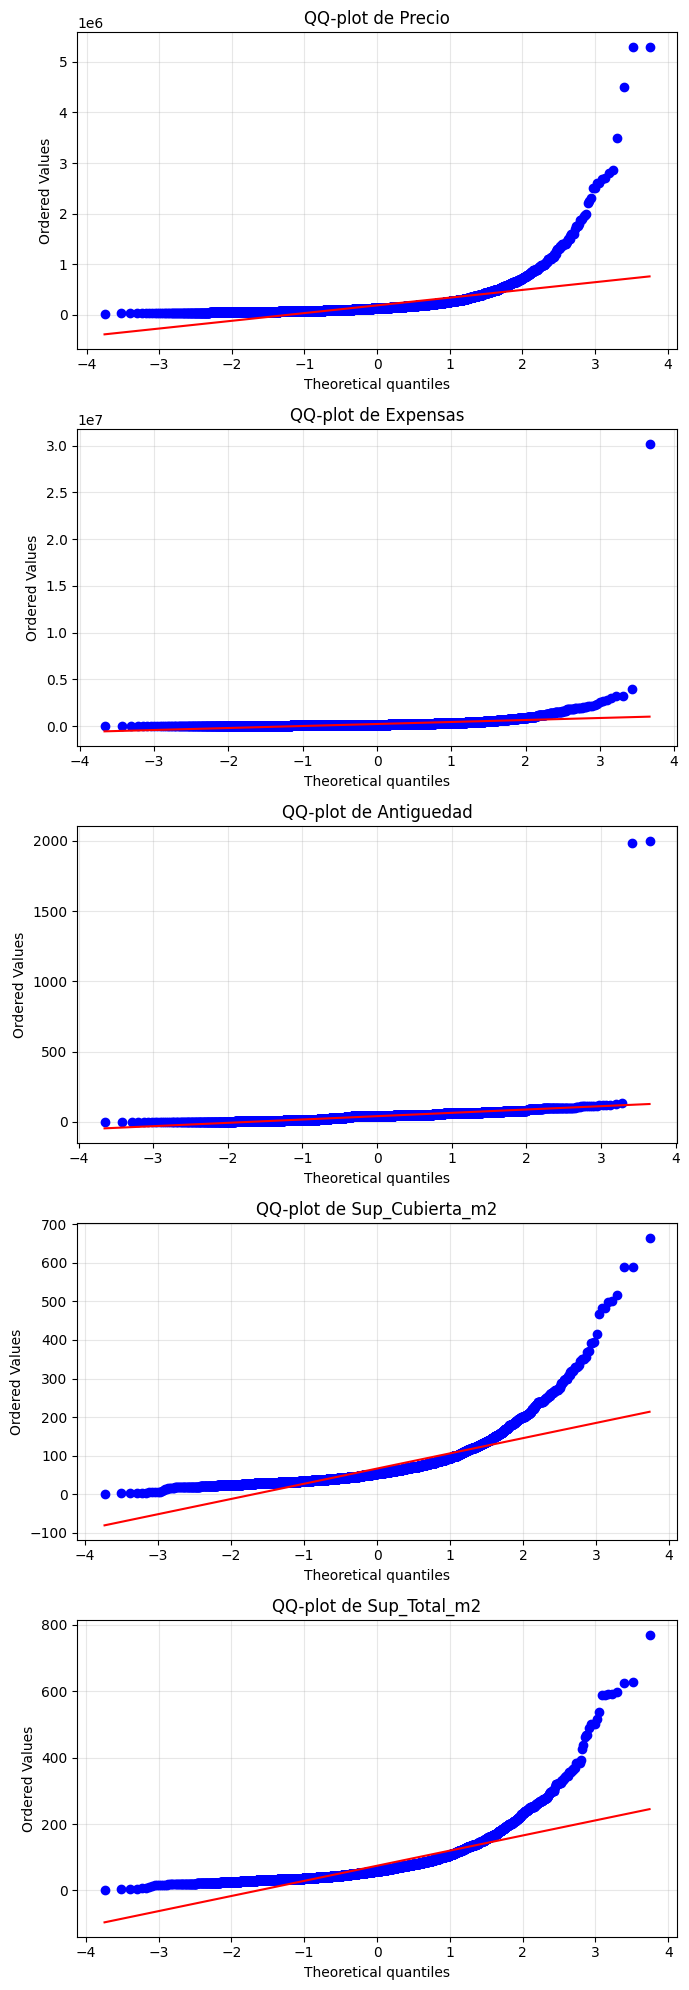

,variable,n,shapiro_stat,shapiro_p_value,dagostino_stat,dagostino_p_value,skewness,kurtosis,normal_shapiro_5pct,normal_dagostino_5pct
0,Precio,7925,0.476386,3.770594e-81,11165.440322,0.0,8.141608,121.648960,False,False
1,Expensas,5687,0.194401,8.414579e-91,17505.136084,0.0,46.341298,2911.545510,False,False
2,Antiguedad,5335,0.287747,5.500087e-88,14587.365429,0.0,33.824898,1514.219288,False,False
3,Sup_Cubierta_m2,7388,0.710054,8.254411e-69,5527.695482,0.0,3.365813,20.021186,False,False
4,Sup_Total_m2,7631,0.695617,8.739107e-70,5785.796895,0.0,3.420862,20.551275,False,False


In [10]:
variables = [
    "Precio",
    "Expensas",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]
variables = [v for v in variables if v in df.columns]

resultados_normalidad = []

fig, axes = plt.subplots(
    nrows=len(variables),
    ncols=1,
    figsize=(7, 4 * len(variables))
)

if len(variables) == 1:
    axes = [axes]

for ax, var in zip(axes, variables):
    x = pd.to_numeric(df[var], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

    if len(x) >= 3:
        x_shapiro = x.sample(5000, random_state=42) if len(x) > 5000 else x
        shapiro_stat, shapiro_p = shapiro(x_shapiro)
        dagostino_stat, dagostino_p = normaltest(x) if len(x) >= 8 else (np.nan, np.nan)

        resultados_normalidad.append({
            "variable": var,
            "n": len(x),
            "shapiro_stat": shapiro_stat,
            "shapiro_p_value": shapiro_p,
            "dagostino_stat": dagostino_stat,
            "dagostino_p_value": dagostino_p,
            "skewness": skew(x),
            "kurtosis": kurtosis(x)
        })

        probplot(x, dist="norm", plot=ax)
        ax.set_title(f"QQ-plot de {var}")
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f"{var}: datos insuficientes")
        ax.axis("off")

plt.tight_layout()
plt.show()

resultados_normalidad = pd.DataFrame(resultados_normalidad)

if not resultados_normalidad.empty:
    resultados_normalidad["normal_shapiro_5pct"] = resultados_normalidad["shapiro_p_value"] > 0.05
    resultados_normalidad["normal_dagostino_5pct"] = resultados_normalidad["dagostino_p_value"] > 0.05

resultados_normalidad

## Transformación logarítmica y outliers

In [11]:
vars_transformar = [
    "Precio",
    "Expensas",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]
vars_transformar = [v for v in vars_transformar if v in df.columns]

for var in vars_transformar:
    df[var] = pd.to_numeric(df[var], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df.loc[df[var] < 0, var] = np.nan
    df[f"log_{var}"] = np.log1p(df[var])
    media = df[f"log_{var}"].mean(skipna=True)
    desvio = df[f"log_{var}"].std(skipna=True)
    df[f"z_log_{var}"] = (df[f"log_{var}"] - media) / desvio if desvio and not np.isnan(desvio) else np.nan

cols_check = []
for var in vars_transformar:
    cols_check.extend([var, f"log_{var}", f"z_log_{var}"])

df[cols_check].head()

,Precio,log_Precio,z_log_Precio,Expensas,log_Expensas,z_log_Expensas,Antiguedad,log_Antiguedad,z_log_Antiguedad,Sup_Cubierta_m2,log_Sup_Cubierta_m2,z_log_Sup_Cubierta_m2,Sup_Total_m2,log_Sup_Total_m2,z_log_Sup_Total_m2
0,2500000.0,14.731802,4.293429,2400000.0,14.690980,3.170962,17.0,2.890372,-0.674881,280.0,5.638355,3.001300,280.0,5.638355,2.719658
1,150000.0,11.918397,0.118136,260000.0,12.468441,0.518326,30.0,3.433987,-0.031699,60.0,4.110874,0.096131,60.0,4.110874,-0.084743
2,330000.0,12.706851,1.288258,203300.0,12.222443,0.224724,NaN,NaN,NaN,90.0,4.510860,0.856878,96.0,4.574711,0.766846
3,270000.0,12.506181,0.990449,300000.0,12.611541,0.689119,20.0,3.044522,-0.492496,87.0,4.477337,0.793120,87.0,4.477337,0.588070
4,570000.0,13.253393,2.099366,1000000.0,13.815512,2.126077,40.0,3.713572,0.299094,140.0,4.948760,1.689736,160.0,5.081404,1.697117


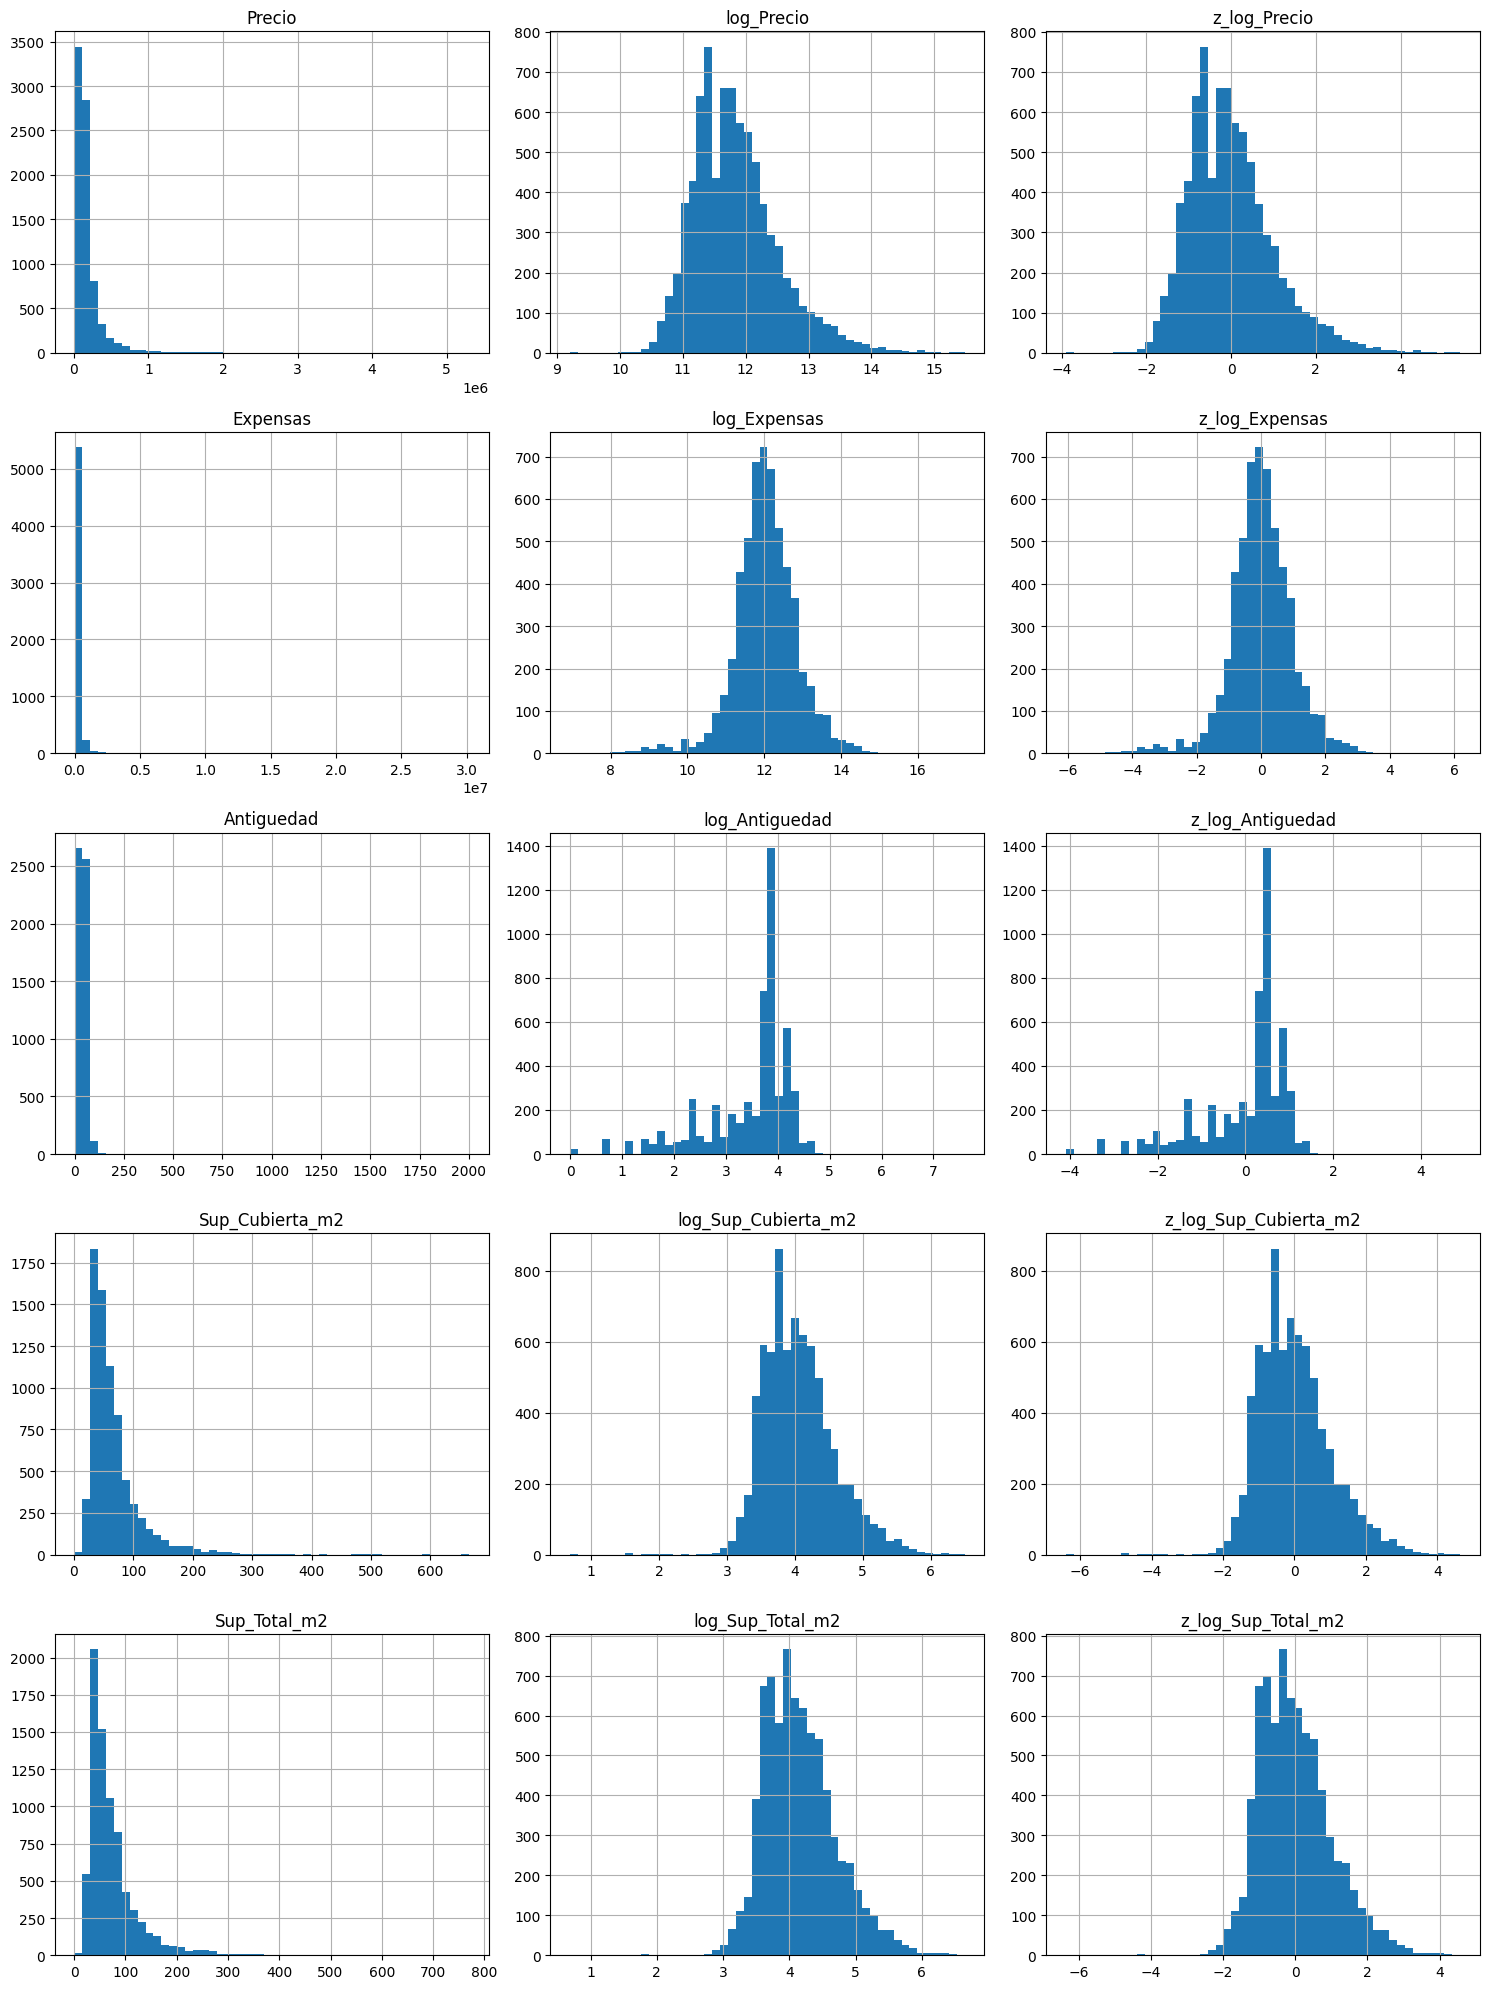

In [12]:
variables = [
    "Precio",
    "Expensas",
    "Antiguedad",
    "Sup_Cubierta_m2",
    "Sup_Total_m2"
]

variables = [v for v in variables if v in df.columns]

fig, axes = plt.subplots(
    nrows=len(variables),
    ncols=3,
    figsize=(15, 4 * len(variables))
)

if len(variables) == 1:
    axes = np.array([axes])

for i, var in enumerate(variables):
    df[var] = pd.to_numeric(df[var], errors="coerce").replace([np.inf, -np.inf], np.nan)
    df.loc[df[var] < 0, var] = np.nan

    df[f"log_{var}"] = np.log1p(df[var])

    media = df[f"log_{var}"].mean(skipna=True)
    desvio = df[f"log_{var}"].std(skipna=True)

    df[f"z_log_{var}"] = (
        (df[f"log_{var}"] - media) / desvio
        if desvio and not np.isnan(desvio)
        else np.nan
    )

    df[var].hist(ax=axes[i, 0], bins=50)
    axes[i, 0].set_title(var)

    df[f"log_{var}"].hist(ax=axes[i, 1], bins=50)
    axes[i, 1].set_title(f"log_{var}")

    df[f"z_log_{var}"].hist(ax=axes[i, 2], bins=50)
    axes[i, 2].set_title(f"z_log_{var}")

plt.tight_layout()
plt.show()


In [13]:
outlier_tables = {}

for var in vars_transformar:
    z_col = f"z_log_{var}"
    outliers = df[df[z_col].abs() > 3].copy()
    outlier_tables[var] = outliers[[var, f"log_{var}", z_col]].sort_values(z_col, ascending=False)
    print(f"{var}: {len(outliers)} outliers")

outlier_tables["Precio"].head(20)

Precio: 80 outliers
Expensas: 90 outliers
Antiguedad: 95 outliers
Sup_Cubierta_m2: 58 outliers
Sup_Total_m2: 51 outliers


,Precio,log_Precio,z_log_Precio
7821,5300000.0,15.483218,5.408583
4840,5300000.0,15.483218,5.408583
4899,4500000.0,15.319588,5.165746
4836,3500000.0,15.068274,4.792777
7379,2870844.0,14.870117,4.498698
4848,2800000.0,14.845130,4.461616
7366,2700000.0,14.808763,4.407644
5489,2690000.0,14.805052,4.402138
5182,2600000.0,14.771022,4.351635
4462,2600000.0,14.771022,4.351635


In [14]:
vars_z = [f"z_log_{var}" for var in vars_transformar if f"z_log_{var}" in df.columns]
mask_outliers = (df[vars_z].abs() > 3).any(axis=1)

print("Filas antes:", df.shape[0])
print("Outliers a eliminar:", mask_outliers.sum())

df = df.loc[~mask_outliers].copy()

print("Filas despu?s:", df.shape[0])

Filas antes: 7980
Outliers a eliminar: 293
Filas despu?s: 7687


## Imputación y tratamiento de NAs

In [15]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_percentages = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
	'Missing Count': missing_counts,
	'Missing Percentage': missing_percentages
})
missing_summary

,Missing Count,Missing Percentage
Toilettes,7120,92.623910
Tipo_Balcon,6679,86.886952
Estado_Edificio,5147,66.957200
Deptos_Por_Piso,5021,65.318069
Cant_Pisos_Edificio,4704,61.194224
...,...,...
Paradas_colectivo_300m,0,0.000000
Dist_Supermercado_m,0,0.000000
Dist_Gimnasio_m,0,0.000000
Supermercados_500m,0,0.000000


In [16]:
df = df.drop(
    columns=[
        "Precio_Ficha", "Expensas_Ficha", "Procesada", "Toilettes", "Tipo_Balcon",
        "Estado_Edificio", "Deptos_Por_Piso", "Cant_Pisos_Edificio", "Detalles", "Descripción"
    ],
    errors="ignore"
)

df = df.dropna(subset=[c for c in ["Comuna", "Barrio", "Baños"] if c in df.columns]).copy()

df.isna().sum().sort_values(ascending=False)

Piso                      3624
Tipo_Unidad               2721
Estado                    2366
log_Antiguedad            2295
z_log_Antiguedad          2295
                          ... 
Paradas_colectivo_300m       0
Dist_Supermercado_m          0
Dist_Gimnasio_m              0
Supermercados_500m           0
Dist_Avenida_m               0
Length: 67, dtype: int64

Dropeamos columnas repetidas como Precio_Ficha y Expensas_Ficha y variables que consideramos poco relevantes que presentaban una alta proporción de valores faltantes


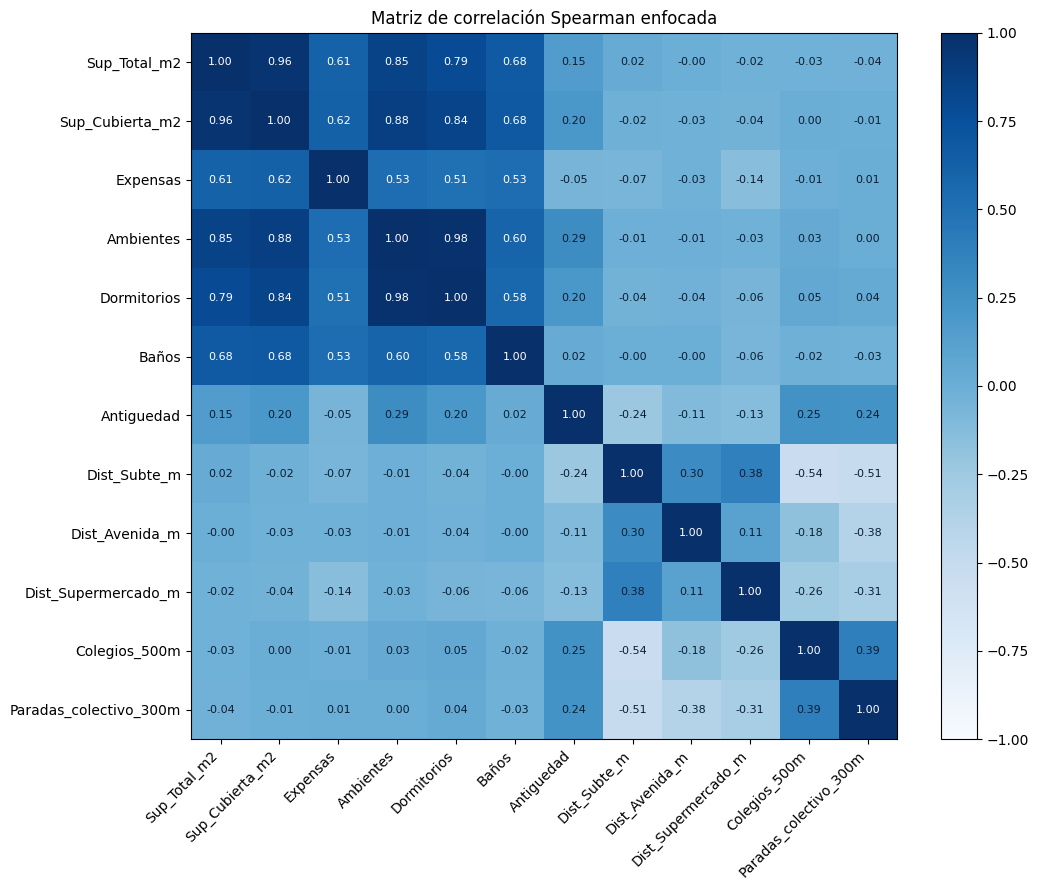

In [20]:
variables_corr = [
    "log_precio",
    "Precio_m2_total",
    "Sup_Total_m2",
    "Sup_Cubierta_m2",
    "Expensas",
    "Ambientes",
    "Dormitorios",
    "Ba\u00f1os",
    "Antiguedad",
    "Dist_Subte_m",
    "Dist_Avenida_m",
    "Dist_Supermercado_m",
    "Colegios_500m",
    "Paradas_colectivo_300m"
]
variables_corr = [col for col in variables_corr if col in df.columns]

df_corr = df[variables_corr].apply(pd.to_numeric, errors="coerce")
df_corr = df_corr.dropna(axis=1, how="all")

corr = df_corr.corr(method="spearman")

fig, ax = plt.subplots(figsize=(12, 9))

# Escala azul: valores bajos claros, valores altos oscuros
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="Blues")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))

ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

ax.set_title("Matriz de correlación Spearman enfocada")

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]

        if pd.notna(valor):
            ax.text(
                j,
                i,
                f"{valor:.2f}",
                ha="center",
                va="center",
                color="white" if valor > 0.45 else "#0B1F33",
                fontsize=8
            )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
df_imputed = df.copy()

knn_cols = [
    "Precio", "Expensas", "Sup_Cubierta_m2", "Sup_Total_m2", "Ambientes",
    "Dormitorios"]
knn_cols = [c for c in knn_cols if c in df_imputed.columns]

for col in knn_cols:
    df_imputed[col] = pd.to_numeric(df_imputed[col], errors="coerce")

df_imputed[knn_cols] = df_imputed[knn_cols].replace([np.inf, -np.inf], np.nan)

imputer = KNNImputer(n_neighbors=5, weights="distance", keep_empty_features=True)
imputed_array = imputer.fit_transform(df_imputed[knn_cols])

df_imputed[knn_cols] = pd.DataFrame(
    imputed_array,
    columns=knn_cols,
    index=df_imputed.index
)

# Fallback con mediana para garantizar que no queden NAs en las variables num?ricas imputadas.
df_imputed[knn_cols] = df_imputed[knn_cols].fillna(df_imputed[knn_cols].median(numeric_only=True))

# Variables discretas que conviene dejar como enteros despues del KNN.
# Baños no se imputa: las filas sin Baños se dropean antes del KNN.
for col in ["Ambientes", "Dormitorios", "Piso", "Antiguedad", "Comuna"]:
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].round().astype("Int64")

mask_sup = df_imputed["Sup_Cubierta_m2"] > df_imputed["Sup_Total_m2"]
df_imputed.loc[mask_sup, "Sup_Cubierta_m2"] = df_imputed.loc[mask_sup, "Sup_Total_m2"]

print("NAs despu?s de imputar variables num?ricas:")
print(df_imputed[knn_cols].isna().sum().sort_values(ascending=False).head(20))
print("Filas con Sup_Cubierta_m2 > Sup_Total_m2:", (df_imputed["Sup_Cubierta_m2"] > df_imputed["Sup_Total_m2"]).sum())

NAs despu?s de imputar variables num?ricas:
Precio             0
Expensas           0
Sup_Cubierta_m2    0
Sup_Total_m2       0
Ambientes          0
Dormitorios        0
dtype: int64
Filas con Sup_Cubierta_m2 > Sup_Total_m2: 0


Usamos KNN porque Precio, Expensas, superficies, ambientes y dormitorios están fuertemente relacionados entre sí, lo que permite imputar cada faltante con los valores de propiedades realmente parecidas en vez de aplastar todo a la media/mediana global, preservando la distribución conjunta y los rangos realistas del mercado sin asumir linealidad ni normalidad.

In [ ]:
df_imputed["Piso"] = df_imputed["Piso"].astype(str)
df_imputed["Piso"] = df_imputed["Piso"].replace("<NA>","No disponible")

In [ ]:
fill_values = {
    "Estado": "No disponible",
    "Tipo_Unidad": "No disponible",
    "Disposicion": "No disponible"
}

for col, value in fill_values.items():
    if col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].fillna(value)

# Si quedaron columnas log/z_log con NAs, no las usamos como variables finales.
df_imputed = df_imputed.drop(
    columns=[c for c in df_imputed.columns if c.startswith("log_") or c.startswith("z_log_")],
    errors="ignore"
)

df_imputed.isna().sum().sort_values(ascending=False)

Antiguedad                       2295
Expensas                            0
Calle                               0
Altura                              0
Piso                                0
Link                                0
Ambientes                           0
Dormitorios                         0
Precio                              0
Baños                               0
Estado                              0
Disposicion                         0
Tipo_Unidad                         0
Sup_Cubierta_m2                     0
Sup_Total_m2                        0
Aire_acondicionado_individual       0
Losa_radiante                       0
Gas_natural                         0
Agua_corriente                      0
Balcón                              0
Terraza                             0
Jardín                              0
Patio                               0
Baulera                             0
Cochera                             0
Muebles_de_cocina                   0
Lavarropas  

Estas 3 variables las consideramos relevantes para el análisis por lo que decidimos imputarles "No disponible" en vez de dropearlas como hicimos con otras variables a nuestro criterio menos relevantes

In [ ]:
df = df_imputed.copy()
print("Shape final:", df.shape)
df.head()

Shape final: (7245, 57)


,Precio,Expensas,Calle,Altura,Piso,Link,Ambientes,Dormitorios,Baños,Estado,...,Hospital_cercano,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m
1,150000.0,260000.0,Bulnes,1600.0,No disponible,https://www.argenprop.com/departamento-en-vent...,3,2,1.0,Excelente,...,Dr. J. A. Fernandez,180.353080,10,493.126679,51.727490,20.279331,10,156.788297,Avenida Santa Fe,19
2,330000.0,203300.0,ARAOZ,1200.0,8,https://www.argenprop.com/departamento-en-vent...,4,3,2.0,Bueno,...,R. Gutierrez,188.537726,11,403.114757,429.584392,249.248104,4,96.514964,Avenida Raúl Scalabrini Ortiz,10
3,270000.0,300000.0,Honduras,3900.0,2,https://www.argenprop.com/departamento-en-vent...,4,2,2.0,Excelente,...,Hospital Municipal de Oncologia M. Curie,240.873938,7,891.145341,383.017854,75.243729,7,425.495375,Avenida Coronel Niceto Vega,5
4,570000.0,1000000.0,Castex,3300.0,No disponible,https://www.argenprop.com/departamento-en-vent...,4,3,3.0,No disponible,...,Dr. J. A. Fernandez,256.797592,4,804.138281,286.697993,217.075594,3,108.444119,Avenida Casares,7
5,98000.0,150000.0,GURRUCHAGA,2100.0,5,https://www.argenprop.com/departamento-en-vent...,1,1,1.0,Muy Bueno,...,R. Gutierrez,153.610169,5,461.483469,393.568008,85.286744,6,378.802881,Avenida Raúl Scalabrini Ortiz,7


In [ ]:
from scipy.stats import spearmanr, kruskal

target = "Antiguedad"


resultados_antiguedad = []

df_test = df_imputed.copy()

df_test[target] = pd.to_numeric(df_test[target], errors="coerce")
df_test[target] = df_test[target].replace([np.inf, -np.inf], np.nan)
df_test.loc[df_test[target] < 0, target] = np.nan

for col in df_test.columns:
    if col == target:
        continue

    temp = df_test[[target, col]].dropna()

    if temp.empty or temp[target].nunique() <= 1:
        continue

    # Numerica vs Antiguedad: Spearman
    if pd.api.types.is_numeric_dtype(temp[col]):
        if temp[col].nunique() > 1:
            corr, p_value = spearmanr(temp[target], temp[col])

            resultados_antiguedad.append({
                "variable": col,
                "tipo": "numerica",
                "test": "Spearman",
                "estadistico": corr,
                "abs_estadistico": abs(corr),
                "p_value": p_value,
                "n": len(temp),
                "categorias": np.nan
            })

    # Categorica vs Antiguedad: Kruskal-Wallis
    else:
        grupos = [
            grupo[target].dropna()
            for _, grupo in temp.groupby(col)
            if len(grupo[target].dropna()) >= 20
        ]

        if len(grupos) >= 2:
            stat, p_value = kruskal(*grupos)

            resultados_antiguedad.append({
                "variable": col,
                "tipo": "categorica",
                "test": "Kruskal-Wallis",
                "estadistico": stat,
                "abs_estadistico": np.nan,
                "p_value": p_value,
                "n": len(temp),
                "categorias": temp[col].nunique()
            })

resultados_antiguedad = pd.DataFrame(resultados_antiguedad)

resultados_antiguedad.sort_values(
    ["p_value", "abs_estadistico"],
    ascending=[True, False]
)


,variable,tipo,test,estadistico,abs_estadistico,p_value,n,categorias
26,Pileta,numerica,Spearman,-0.359542,0.359542,5.884501e-151,4950,NaN
34,Barrio,categorica,Kruskal-Wallis,729.317100,NaN,7.559454e-127,4950,48.0
8,Estado,categorica,Kruskal-Wallis,592.503510,NaN,8.424609e-126,4950,6.0
33,Longitud,numerica,Spearman,0.307847,0.307847,3.870100e-109,4950,NaN
40,Hospital_cercano,categorica,Kruskal-Wallis,605.469746,NaN,4.726427e-109,4950,35.0
37,Subte_cercano,categorica,Kruskal-Wallis,716.873399,NaN,5.390843e-109,4950,84.0
48,Avenida_cercana,categorica,Kruskal-Wallis,679.602739,NaN,3.435091e-103,4950,151.0
5,Ambientes,numerica,Spearman,0.285021,0.285021,3.666292e-93,4950,NaN
27,Parrilla,numerica,Spearman,-0.277669,0.277669,2.529071e-88,4950,NaN
35,Comuna,numerica,Spearman,-0.264327,0.264327,6.452903e-80,4950,NaN


In [ ]:
target = "Antiguedad"
min_n = 10

# Importante: trabajar como float durante toda la imputacion
df_imputed[target] = pd.to_numeric(df_imputed[target], errors="coerce").astype("float64")
df_imputed[target] = df_imputed[target].replace([np.inf, -np.inf], np.nan)
df_imputed.loc[df_imputed[target] < 0, target] = np.nan

df_imputed["Antiguedad_imputada"] = df_imputed[target].isna().astype(int)

print("NAs antes:", df_imputed[target].isna().sum())


def imputar_mediana_jerarquica(df, target, group_cols, min_n=10):
    stats = (
        df.loc[df[target].notna()]
        .groupby(group_cols, dropna=False)[target]
        .agg(["median", "count"])
        .reset_index()
    )

    stats = stats[stats["count"] >= min_n].copy()

    if stats.empty:
        return df[target]

    stats = stats.rename(columns={"median": "mediana_grupo"})

    mediana_grupo = (
        df[group_cols]
        .merge(
            stats[group_cols + ["mediana_grupo"]],
            on=group_cols,
            how="left"
        )["mediana_grupo"]
    )

    mediana_grupo = pd.to_numeric(mediana_grupo, errors="coerce")
    mediana_grupo.index = df.index

    resultado = df[target].copy()
    mask = resultado.isna() & mediana_grupo.notna()
    resultado.loc[mask] = mediana_grupo.loc[mask]

    return resultado.astype("float64")


jerarquia_grupos = [
    ["Barrio", "Estado", "Tipo_Unidad", "Ambientes"],
    ["Barrio", "Estado", "Ambientes"],
    ["Barrio", "Estado", "Tipo_Unidad"],

    ["Comuna", "Estado", "Tipo_Unidad", "Ambientes"],
    ["Comuna", "Estado", "Ambientes"],
    ["Comuna", "Estado", "Tipo_Unidad"],

    ["Barrio", "Estado"],
    ["Comuna", "Estado"],

    ["Barrio", "Tipo_Unidad"],
    ["Comuna", "Tipo_Unidad"],

    ["Barrio"],
    ["Comuna"],
    ["Estado"],
    ["Tipo_Unidad"]
]


for grupo in jerarquia_grupos:
    faltantes_antes = df_imputed[target].isna().sum()

    if faltantes_antes == 0:
        break

    df_imputed[target] = imputar_mediana_jerarquica(
        df=df_imputed,
        target=target,
        group_cols=grupo,
        min_n=min_n
    )

    faltantes_despues = df_imputed[target].isna().sum()

    print(
        grupo,
        "| imputados:",
        faltantes_antes - faltantes_despues,
        "| faltantes restantes:",
        faltantes_despues
    )


df_imputed[target] = df_imputed[target].fillna(df_imputed[target].median())

# Recién ahora la dejamos como entera
df_imputed[target] = df_imputed[target].round().astype("Int64")

print("NAs despues:", df_imputed[target].isna().sum())


NAs antes: 2295
['Barrio', 'Estado', 'Tipo_Unidad', 'Ambientes'] | imputados: 688 | faltantes restantes: 1607
['Barrio', 'Estado', 'Ambientes'] | imputados: 395 | faltantes restantes: 1212
['Barrio', 'Estado', 'Tipo_Unidad'] | imputados: 576 | faltantes restantes: 636
['Comuna', 'Estado', 'Tipo_Unidad', 'Ambientes'] | imputados: 244 | faltantes restantes: 392
['Comuna', 'Estado', 'Ambientes'] | imputados: 232 | faltantes restantes: 160
['Comuna', 'Estado', 'Tipo_Unidad'] | imputados: 61 | faltantes restantes: 99
['Barrio', 'Estado'] | imputados: 35 | faltantes restantes: 64
['Comuna', 'Estado'] | imputados: 51 | faltantes restantes: 13
['Barrio', 'Tipo_Unidad'] | imputados: 13 | faltantes restantes: 0
NAs despues: 0


Usamos imputación jerárquica por mediana de grupo (Barrio → Estado → Tipo_Unidad → Ambientes, con fallbacks progresivamente más laxos) porque los tests de Spearman y Kruskal-Wallis mostraron que Antiguedad se asocia mucho más con variables categóricas urbanas (barrio, estado, tipo de unidad) que con las numéricas continuas, por lo que KNN sobre features numéricas no habría capturado bien esa estructura.

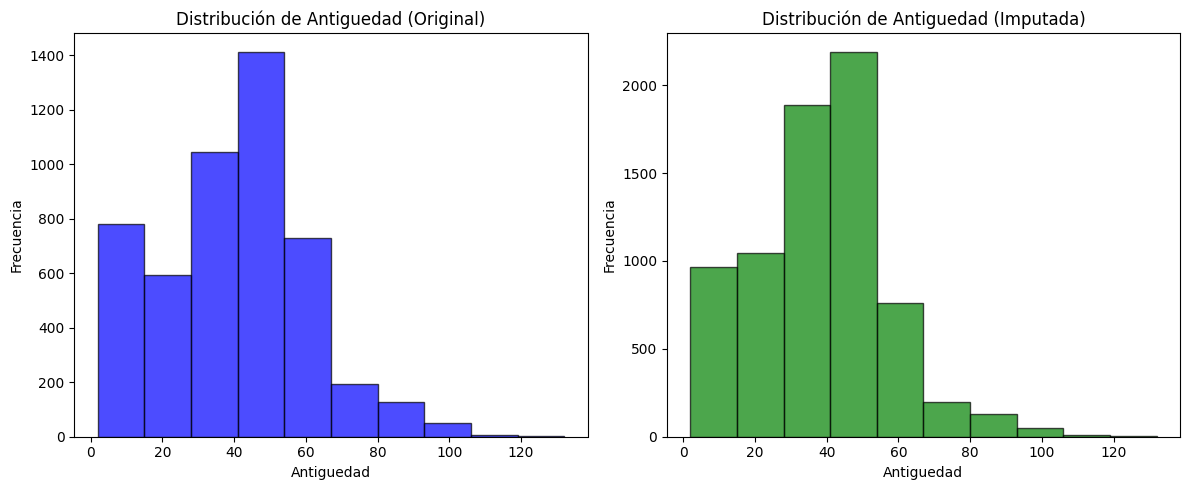

In [ ]:
import matplotlib.pyplot as plt

# Histogram for original df (dropping NAs in Antiguedad)
antiguedad_original = df['Antiguedad'].dropna()

# Histogram for df_imputed (Antiguedad imputed)
antiguedad_imputed = df_imputed['Antiguedad'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(antiguedad_original, bins=10, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Distribución de Antiguedad (Original)')
axes[0].set_xlabel('Antiguedad')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(antiguedad_imputed, bins=10, alpha=0.7, color='green', edgecolor='black')
axes[1].set_title('Distribución de Antiguedad (Imputada)')
axes[1].set_xlabel('Antiguedad')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [ ]:
df_imputed.isna().sum().sort_values(ascending=False)

Precio                           0
Expensas                         0
Calle                            0
Altura                           0
Piso                             0
Link                             0
Ambientes                        0
Dormitorios                      0
Baños                            0
Estado                           0
Antiguedad                       0
Disposicion                      0
Tipo_Unidad                      0
Sup_Cubierta_m2                  0
Sup_Total_m2                     0
Aire_acondicionado_individual    0
Losa_radiante                    0
Gas_natural                      0
Agua_corriente                   0
Balcón                           0
Terraza                          0
Jardín                           0
Patio                            0
Baulera                          0
Cochera                          0
Muebles_de_cocina                0
Lavarropas                       0
Lavavajillas                     0
Permite_Mascotas    

In [ ]:
columnas_sin_variabilidad = [col for col in df_imputed.columns if df_imputed[col].nunique(dropna=False) <= 1]

print(f"Columnas eliminadas por no tener variabilidad: {len(columnas_sin_variabilidad)}")
columnas_sin_variabilidad


Columnas eliminadas por no tener variabilidad: 5


['Lavarropas', 'Lavavajillas', 'Piscina', 'SUM', 'Seguridad_24hs']

In [ ]:
df_imputed = df_imputed.drop(columns=columnas_sin_variabilidad)

df_imputed.to_csv("Argenprop_limpio.csv")